In [3]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json # in order to work with json files
import geojson # in order to work with geojson files
from area import area #2 calculate the area of the zip code polygons
import plotly.io as pio


In [4]:
df_raw = pd.read_csv("data\eda.csv")
print(df_raw.shape)
df_processed = df_raw.copy()
df_raw.head()

(21597, 21)


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price,date
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0,221900.0,2014-10-13
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0,538000.0,2014-12-09
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0,180000.0,2015-02-25
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0,604000.0,2014-12-09
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0,510000.0,2015-02-18


In [5]:
df_processed[df_processed.duplicated("id", keep = False)]#The 177 duplicates just deviate in price and date (resoled, mb renovated)
df_processed = df_processed.sort_values(by="date", ascending=False).drop_duplicates(subset="id", keep="first")
df_processed.reset_index(drop=True, inplace=True)

In [6]:
df_processed.columns = df_processed.columns.str.lower().str.replace(" ", "_")
df_processed["date"] = pd.to_datetime(df_processed["date"], format="%Y-%m-%d", errors="coerce")# date is an object, but should be a datetime

In [52]:
#Overview of the location of all houses in the dataframe
fig_scatter = px.scatter_mapbox(
    df_processed,
    lat="lat",
    lon="long",
    hover_name="zipcode",
    hover_data=["price", "sqft_living", "bedrooms", "bathrooms"],
    color_discrete_sequence=["blue"],
    zoom=9,
    height=950,
    title="Locations of the available houses"
)

fig_scatter.update_layout(mapbox_style="open-street-map")
pio.write_image(fig_scatter.update_layout(mapbox_style="open-street-map"), r"plots/01_overview.svg", width=3.2*dpi, height=3*dpi, scale=2) #overview


Filter parameters

In [66]:
medium = 10000 #ft², above this value the house is considered as isolated
threshold_b_b = 1800 #ft², above this value the house is considered to accommodate a family with children
threshold_center_dist = 20 #km  #km, above this value the house is considered to be not close to the center of the city
grade = 7 # grade of the house, above this value the house is considered to be nice

In [28]:
# Nice houses
df_nice_houses_nr = df_processed[df_processed["grade"]>=grade].count()[0] # 6.5 is the average grade, so we can say that houses with a grade of 7 are above average and therefore nice.
print("Number of nice houses: ", df_nice_houses_nr)

df_nice_houses = df_processed[df_processed["grade"]>=grade]

fig_nice_houses = px.scatter_mapbox(
    df_nice_houses,
    lat="lat",
    lon="long",
    hover_name="zipcode",
    hover_data=["price", "sqft_living", "bedrooms", "bathrooms"],
    color_discrete_sequence=["blue"],
    zoom=8,
    height=550,
    width = 500,
    title="Nice houses"
)
fig_nice_houses.update_layout(mapbox_style="open-street-map")

Number of nice houses:  19163


Number of isolated houses:  5491


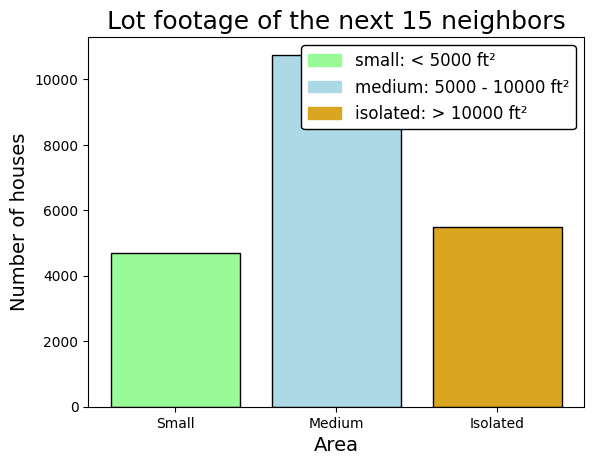

In [ ]:
#isolated houses: sqft_lot15 
small = 5000

df_isolated_small = df_processed[(df_processed["sqft_lot15"] < small)]
df_isolated_medium = df_processed[(df_processed["sqft_lot15"] < medium) & (df_processed["sqft_lot15"] > small)]
df_isolated_isolated = df_processed[df_processed["sqft_lot15"] > medium] 

y = [df_isolated_small.count()[0], df_isolated_medium.count()[0], df_isolated_isolated.count()[0]]
x = ["Small", "Medium", "Isolated"]

plt.bar(x,y, color= ("palegreen", "lightblue", "goldenrod", "dimgray"), edgecolor="black")
plt.title('Lot footage of the next 15 neighbors', fontsize=18)
plt.xlabel('Area', fontsize=14)
plt.ylabel('Number of houses', fontsize=14)
colors = {"small: < 5000 ft²":"palegreen", "medium: 5000 - 10000 ft²" :"lightblue", "isolated: > 10000 ft²" : "goldenrod"}         
labels = list(colors.keys())
handles = [plt.Rectangle((0,0),1,1, color=colors[label]) for label in labels]
plt.legend(handles, labels, fontsize=12, facecolor='white', framealpha=1, edgecolor='black', loc='upper right')
#plt.savefig(r"plots/20_lot_neighbor.svg", dpi=300)

df_isolated_houses_nr = df_isolated_isolated.count()[0]
print("Number of isolated houses: ", df_isolated_houses_nr)
df_isolated_houses = df_isolated_isolated.copy()

fig_scatter_isolated = px.scatter_mapbox(
    df_isolated_houses,
    lat="lat",
    lon="long",
    hover_name="zipcode",
    hover_data=["price", "sqft_living", "bedrooms", "bathrooms"],
    color_discrete_sequence=["blue"],
    zoom=8,
    height=550,
    width = 500,
    title="Isolated houses"
)
fig_scatter_isolated.update_layout(mapbox_style="open-street-map")

Number of houses with living space < 1600 ft² = 7132


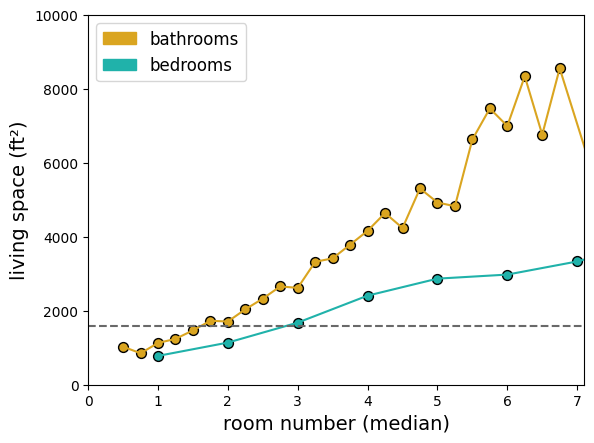

In [ ]:
# here we try to find out where is the living space threshold , for houses with bedrooms <=3  and bathrooms <=2 


df_kid_less_nr =df_processed[df_processed["sqft_living15"] < threshold_b_b].count()[0]

print(f"Number of houses with living space < {threshold_b_b} ft² = {df_kid_less_nr}") 

df_grpt_bedr = df_processed.groupby("bedrooms").median()
df_grpt_bedr = df_grpt_bedr.reset_index()
y = list(df_grpt_bedr["sqft_living"])
x = list(df_grpt_bedr["bedrooms"])
plt.scatter(x,y, color = "lightseagreen", edgecolors="black", s = 50)
plt.plot(x,y, color = "lightseagreen")
#plt.title("Bedrooms vs. Living Space", fontsize = 18)
plt.xlim(0, 7.1)
plt.ylim(0, 10000)
plt.xlabel("room number (median)", fontsize = 14)
plt.ylabel("living space (ft²)", fontsize = 14)


df_grpt_bath = df_processed.groupby("bathrooms").median()
df_grpt_bath = df_grpt_bath.reset_index()
y = list(df_grpt_bath["sqft_living"])
x = list(df_grpt_bath["bathrooms"])
plt.scatter(x,y, color = "goldenrod", edgecolors="black", s = 50)
plt.plot(x,y, color = "goldenrod")
plt.axhline(y=threshold_b_b, color='dimgray', linestyle='--', label='2000 ft²')

colors = {"bathrooms" :"goldenrod","bedrooms":"lightseagreen"}         
labels = list(colors.keys())
handles = [plt.Rectangle((0,0),1,1, color=colors[label]) for label in labels]
plt.legend(handles, labels, fontsize=12)

#plt.savefig(r"plots/22_b_b.svg", dpi=300)


df_kid_less =df_processed[df_processed["sqft_living15"] < threshold_b_b]

fig_scatter_kid_less = px.scatter_mapbox(
    df_kid_less,
    lat="lat",
    lon="long",
    hover_name="zipcode",
    hover_data=["price", "sqft_living", "bedrooms", "bathrooms"],
    color_discrete_sequence=["blue"],
    zoom=8,
    height=550,
    width = 500,
    title="Houses with low neighbor-kid-probability"
)
fig_scatter_kid_less.update_layout(mapbox_style="open-street-map")

Center of the city:  47.606086 -122.332911


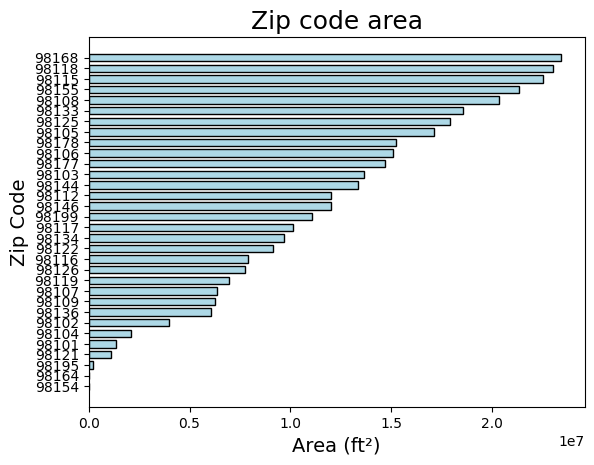

In [ ]:
#getting to know where the center of the city is located. Hypothesis: city center is located where the zip code area is the smallest and the population density is therefore the highest

with open("zip-codes_seattle.geojson") as f: # install geojson with pip install geojson first and the area package with pip install area
    geojson_data = geojson.load(f)

# Calculate the area for each polygon
polygon_areas = []
for feature in geojson_data['features']:
    polygon = feature['geometry']
    polygon_area = area(polygon)
    polygon_areas.append({
        'zipcode': feature['properties']['ZCTA5CE10'],  # Adjust the property key if needed
        'area': polygon_area
    })
# Convert the results to a DataFrame
df_polygon_areas = pd.DataFrame(polygon_areas)

#center, located for the zip code 98154
center_lat = 47.606086
center_long = -122.332911

print ("Center of the city: ", center_lat, center_long)

df_polygon_areas_sorted = df_polygon_areas.sort_values('area')
x = df_polygon_areas_sorted["zipcode"]
y = df_polygon_areas_sorted["area"]
plt.barh(x,y, color="lightblue", edgecolor="black", align='center', height=0.7)
plt.title('Zip code area', fontsize=18)
plt.xlabel('Area (ft²)', fontsize=14)
plt.ylabel('Zip Code', fontsize=14)
#plt.savefig(r"plots/21_zip_code_area.svg", dpi=300)



In [67]:
# distance from the center to the individual houses

from math import radians, cos, sin, asin, sqrt

def haversine_np(lon1, lat1, lon2, lat2):
   
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6378.137 * c
    return km
# Calculate the distance from the center for each entry in df_processed
df_processed['distance_from_center'] = haversine_np(
    df_processed['long'], 
    df_processed['lat'], 
    center_long, 
    center_lat
)

# Create a new DataFrame with id and calculated distance
df_center_houses_nr = df_processed[df_processed["distance_from_center"] < threshold_center_dist].count()[0] # houses within threshold_center_dist km from the center
print("The number of central houses: ", df_center_houses_nr)

df_center_houses = df_processed[df_processed["distance_from_center"] < threshold_center_dist]

fig_center_houses = px.scatter_mapbox(
    df_center_houses,
    lat="lat",
    lon="long",
    hover_name="zipcode",
    hover_data=["price", "sqft_living", "bedrooms", "bathrooms"],
    color_discrete_sequence=["blue"],
    zoom=8,
    height=550,
    width = 500,
    title="Houses with proximity to center"
)
fig_center_houses.update_layout(mapbox_style="open-street-map")



The number of central houses:  13234


In [68]:
#houses with waterfront

df_waterfront = df_processed[df_processed["waterfront"] == 1] #df houses with waterfront

print("Number of houses with waterfront: ", df_waterfront.shape[0])

fig_scatter_waterfront = px.scatter_mapbox(
    df_waterfront,
    lat="lat",
    lon="long",
    hover_name="zipcode",
    hover_data=["price", "sqft_living", "bedrooms", "bathrooms"],
    color_discrete_sequence=["blue"],
    zoom=8,
    height=550,
    width = 500,
    title="Locations of the sold Houses with waterfront"
)
fig_scatter_waterfront.update_layout(mapbox_style="open-street-map")
fig_scatter_waterfront.show()

Number of houses with waterfront:  146


Starting here we will eliminated the houses appying the creteria found earlier

The order is: 
    nice (grade > 7)
    central (< 20 km away from center)
    isolated (15 next neighbors have a lot size > 10000 ft² )
    neighborhood without kids (living space next neighbors < 1800 ft²)
    waterfront (houses with waterfront only)

In [69]:
df_complete = df_center_houses.copy()
dpi = 300 #dpi for saved pictures


Nice houses

In [70]:
# Nice houses
df_nice_houses_nr = df_processed[df_processed["grade"]>=grade].count()[0] # 6.5 is the average grade, so we can say that houses with a grade of 7 are above average and therefore nice.
print("Number of nice houses: ", df_nice_houses_nr)

df_nice_houses = df_processed[df_processed["grade"]>=7]

fig_nice_houses = px.scatter_mapbox(
    df_nice_houses,
    lat="lat",
    lon="long",
    hover_name="zipcode",
    hover_data=["price", "sqft_living", "bedrooms", "bathrooms"],
    color_discrete_sequence=["blue"],
    zoom=9,
    height=950,
    title="Nice houses"
)
fig_nice_houses.update_layout(mapbox_style="open-street-map")

#pio.write_image(fig_nice_houses.update_layout(mapbox_style="open-street-map"), r"plots/02_nice.svg", width=3.2*dpi, height=3*dpi, scale=1) #overview

Number of nice houses:  19163


Nice houses with central location

In [71]:
df_nice_central = df_complete[(df_complete["grade"]>=grade) & (df_complete["distance_from_center"] < threshold_center_dist)]
print(df_nice_central.shape[0])
fig_nice_central = px.scatter_mapbox(
    df_nice_central,
    lat="lat",
    lon="long",
    hover_name="zipcode",
    hover_data=["price", "sqft_living", "bedrooms", "bathrooms"],
    color_discrete_sequence=["blue"],
    zoom=9,
    height=950,
    title="Nice & central houses"
)
fig_nice_central.update_layout(mapbox_style="open-street-map")
#pio.write_image(fig_nice_central.update_layout(mapbox_style="open-street-map"), r"plots/03_nice_central.svg", width=3.2*dpi, height=3*dpi, scale=1) #overview

11618


Nice houses with central location but isolated

In [72]:
df_nice_central_isolated = df_complete[(df_complete["grade"]>=grade) & (df_complete["distance_from_center"] < threshold_center_dist) & (df_complete["sqft_lot15"] > medium)]
print(df_nice_central_isolated.shape[0])
fig_nice_central_isolated = px.scatter_mapbox(
    df_nice_central_isolated,
    lat="lat",
    lon="long",
    hover_name="zipcode",
    hover_data=["price", "sqft_living", "bedrooms", "bathrooms"],
    color_discrete_sequence=["blue"],
    zoom=9,
    height=950,
    title="Nice & central houses, but isolated"
)
fig_nice_central_isolated.update_layout(mapbox_style="open-street-map")
#pio.write_image(fig_nice_central_isolated.update_layout(mapbox_style="open-street-map"), r"plots/04_nice_central_isolated.svg", width=3.2*dpi, height=3*dpi, scale=1) #overview

2272


Nice houses with central location but isolated, in a neighborhood without kids

In [ ]:
df_nice_central_isolated_wokids = df_complete[(df_complete["grade"]>=grade) & (df_complete["distance_from_center"] < threshold_center_dist) & (df_complete["sqft_lot15"] > medium) & (df_complete["sqft_living15"] < threshold_b_b)]
print(df_nice_central_isolated_wokids.shape[0])
fig_nice_central_isolated_wokids = px.scatter_mapbox(
    df_nice_central_isolated_wokids,
    lat="lat",
    lon="long",
    hover_name="zipcode",
    hover_data=["price", "sqft_living", "bedrooms", "bathrooms"],
    color_discrete_sequence=["blue"],
    zoom=9,
    height=950,
    title="Nice & central houses, but isolated & without kids"
)
fig_nice_central_isolated_wokids.update_layout(mapbox_style="open-street-map")
#pio.write_image(fig_nice_central_isolated_wokids.update_layout(mapbox_style="open-street-map"), r"plots/05_nice_central_isolated_wokids.svg", width=3.2*dpi, height=3*dpi, scale=1) #overview

363


Nice houses with central location but isolated, in a neighborhood without kids and a waterfront

In [101]:


df_nice_central_isolated_wokids_waterfront = df_complete[(df_complete["grade"]>=grade) & (df_complete["distance_from_center"] < threshold_center_dist) & (df_complete["sqft_lot15"] > medium) & (df_complete["sqft_living15"] < threshold_b_b) & (df_complete["waterfront"] == 1)]
print(df_nice_central_isolated_wokids_waterfront.shape[0])
fig_nice_central_isolated_wokids_waterfront = px.scatter_mapbox(
    df_nice_central_isolated_wokids_waterfront,
    lat="lat",
    lon="long",
    hover_name="zipcode",
    hover_data=["price", "sqft_living", "sqft_lot", "bedrooms", "bathrooms"],
    color_discrete_sequence=["blue"],
    size = "price",
    zoom=9,
    height=950,
    title="Nice & central houses, but isolated & without kids, but with waterfront"
)
fig_nice_central_isolated_wokids_waterfront.update_layout(mapbox_style="open-street-map")
#pio.write_image(fig_nice_central_isolated_wokids_waterfront.update_layout(mapbox_style="open-street-map"), r"plots/06_nice_central_isolated_wokids_waterfront.svg", width=3.2*dpi, height=3*dpi, scale=1) #overview


6


In [78]:
df_nice_central_isolated_wokids_waterfront.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price,date,distance_from_center
1381,3225069241,3.0,2.50,3490.0,21064.0,1.0,1.0,4.0,3,10,...,1968,0.0,98074,47.6092,-122.073,1780.0,15244.0,2000000.0,2015-04-22,19.509919
3042,6329000185,3.0,2.50,2600.0,23361.0,1.5,1.0,4.0,3,8,...,1912,0.0,98146,47.4997,-122.379,1700.0,14700.0,540000.0,2015-03-29,12.338678
7762,8073000491,4.0,1.75,1950.0,7139.0,1.0,1.0,4.0,3,7,...,1957,0.0,98178,47.5121,-122.248,1600.0,13122.0,700000.0,2014-12-11,12.253594
16105,8073000480,2.0,1.75,1900.0,13122.0,1.0,1.0,4.0,3,7,...,1954,0.0,98178,47.5121,-122.248,1650.0,13160.0,869000.0,2014-07-22,12.253594
18582,2423029009,2.0,2.00,1494.0,19271.0,2.0,1.0,4.0,3,7,...,1943,19970.0,98070,47.4728,-122.497,1494.0,43583.0,465000.0,2014-06-17,19.292641


Final choice, the 3 cheapest houses

In [118]:
df_nice_central_isolated_wokids_waterfront_cheap = df_nice_central_isolated_wokids_waterfront[
    (df_nice_central_isolated_wokids_waterfront["id"] == 6329000185) | 
    (df_nice_central_isolated_wokids_waterfront["id"] == 8073000491) | 
    (df_nice_central_isolated_wokids_waterfront["id"] == 2423029009)
]
print(df_nice_central_isolated_wokids_waterfront_cheap.shape[0])
fig_nice_central_isolated_wokids_waterfront_cheap = px.scatter_mapbox(
    df_nice_central_isolated_wokids_waterfront_cheap,
    lat="lat",
    lon="long",
    hover_name="zipcode",
    hover_data=["price", "sqft_living", "sqft_lot", "bedrooms", "bathrooms", "distance_from_center", "grade"],
    color_discrete_sequence=["blue"],
    size = "price",
    zoom=9,
    height=950,
    title="Nice & central houses, but isolated & without kids, but with waterfront and cheap"
)
fig_nice_central_isolated_wokids_waterfront_cheap.update_layout(mapbox_style="open-street-map")
#pio.write_image(fig_nice_central_isolated_wokids_waterfront_cheap.update_layout(mapbox_style="open-street-map"), r"plots/07_nice_central_isolated_wokids_waterfront_cheap.svg", width=3.2*dpi, height=3*dpi, scale=1) #overview

3


Nice houses with central location but isolated, in a neighborhood without kids and a waterfront (maybe # waterfront != 0)

In [82]:


df_nice_central_isolated_wokids_waterfront_mb = df_complete[(df_complete["grade"]>=grade) & (df_complete["distance_from_center"] < threshold_center_dist) & (df_complete["sqft_lot15"] > medium) & (df_complete["sqft_living15"] < threshold_b_b) & (df_complete["waterfront"] != 0) & (df_complete["waterfront"] != 1)]
print(df_nice_central_isolated_wokids_waterfront_mb.shape[0])
fig_nice_central_isolated_wokids_waterfront_mb = px.scatter_mapbox(
    df_nice_central_isolated_wokids_waterfront_mb,
    lat="lat",
    lon="long",
    hover_name="zipcode",
    hover_data=["price", "sqft_living", "sqft_lot", "bedrooms", "bathrooms"],
    color_discrete_sequence=["blue"],
    zoom=10,
    height=950,
    title="Nice & central houses, but isolated & without kids, but with waterfront (maybe)"
)
fig_nice_central_isolated_wokids_waterfront_mb.update_layout(mapbox_style="open-street-map")
#pio.write_image(fig_nice_central_isolated_wokids_waterfront_mb.update_layout(mapbox_style="open-street-map"), r"plots/07_nice_central_isolated_wokids_waterfront_mb.svg", width=3.2*dpi, height=3*dpi, scale=1) #overview


42


How waterfront influences the price

Houses with waterfront have a median price of 1700000.0 $
Houses without waterfront have a median price of 500000.0 $


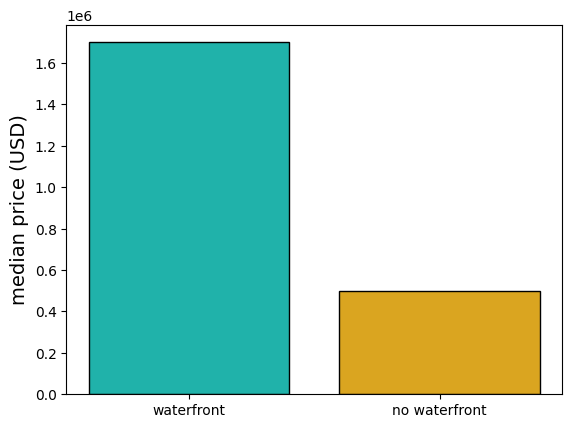

In [ ]:
df_waterfront_price = df_complete[df_complete["waterfront"] == 1].median()["price"]
df_waterfront_wo_price = df_complete[df_complete["waterfront"] == 0].median()["price"]
print(f"Houses with waterfront have a median price of {df_waterfront_price} $")
print(f"Houses without waterfront have a median price of {df_waterfront_wo_price} $")

y = [df_waterfront_price, df_waterfront_wo_price]
x = ["waterfront", "no waterfront"]

plt.bar(x,y, color= ("lightseagreen", "goldenrod"), edgecolor="black")
#plt.title('median price of houses with and without waterfront', fontsize=18)
plt.ylabel('median price (USD)', fontsize=14)
#plt.savefig(r"plots/23_waterfront.svg", dpi=300)